# Acquiring the data for Berlin

### Import Required Libraries

In [1]:
import xarray as xr
import rioxarray
import pandas as pd
from distributed import LocalCluster
import folium
from datetime import datetime
import s3fs
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.dates as mdates
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import json
from scipy.interpolate import griddata
from pathlib import Path
import geopandas as gpd
import netCDF4
from shapely.geometry import box

In [2]:
xr.set_options(keep_attrs=True)

### Dask Cluster Initialization


This creates a local Dask cluster and retrieves its client for distributed parallel processing.


In [3]:
cluster = LocalCluster()
client = cluster.get_client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 4,Total memory: 10.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34019,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:45733,Total threads: 1
Dashboard: http://127.0.0.1:38785/status,Memory: 2.50 GiB
Nanny: tcp://127.0.0.1:41749,


### Reading the bbox 

The area of interest covers London and its 70 km buffer 

In [4]:
def read_json(filename: str) -> dict:
    with open(filename) as input:
        field = json.load(input)
    return field


city_name = 'Berlin'
aoi = read_json(f"data/{city_name}_bbox.geojson")

start_date = datetime(2023, 6, 1)
end_date = datetime(2023, 9, 30)

### Visualize Area of Interest

In [5]:
m = folium.Map()
folium.GeoJson(aoi).add_to(m)
m

Calculate the extent of geojson

In [6]:
def calculate_geojson_extent(geojson_path):
    with open(geojson_path) as f:
        geojson_data = json.load(f)
    gdf = gpd.GeoDataFrame.from_features(geojson_data["features"]).explode().cx[0:, :]
    return gdf.total_bounds


geojson_path = Path(f"data/{city_name}_bbox.geojson")
extent = calculate_geojson_extent(geojson_path)
print(f"Extent of the geojson: {extent}")

Extent of the geojson: [12.41653116 51.92556437 14.43485657 53.07934812]


(Data_Access_HEAT)=
## Data Access

We now want to access a time series of Sentinel-3 data to compute the daily temperature values, remove cloudy pixels, and perform other processing steps.

### List of Available Remote Files

In [7]:
bucket = "e05ab01a9d56408d82ac32d69a5aae2a:sample-data"
prefixes = ["tutorial_data/cpm_v253/", "tutorial_data/cpm_v256/"]
prefix_url = "https://objects.eodc.eu"

fs = s3fs.S3FileSystem(anon=True, client_kwargs={"endpoint_url": prefix_url})

# Unregister CEPH handler (required for EODC)
handlers = fs.s3.meta.events._emitter._handlers
handlers_to_unregister = handlers.prefix_search("before-parameter-build.s3")
fs.s3.meta.events._emitter.unregister(
    "before-parameter-build.s3", handlers_to_unregister[0]
)

filtered_urls = []

for prefix in prefixes:
    # Find all potential Sentinel-3 LST datasets
    s3_pattern = f"s3://{bucket}/{prefix}S3[AB]_SL_2_LST____*.zarr"
    candidates = fs.glob(s3_pattern)

    for s3_path in candidates:
        # Convert S3 path to HTTP URL
        http_url = f"{prefix_url}/{s3_path.replace('s3://', '')}"

        # Extract filename from URL
        filename = s3_path.split("/")[-1]

        # Parse sensing start time (4th segment after splitting by '_')
        try:
            # Split: S3B_SL_2_LST____20231029T203741_20231029T204041_...
            time_segment = filename.split("____")[1]
            sensing_start = time_segment.split("_")[0]  # 20231029T203741
            file_date = datetime.strptime(sensing_start[:8], "%Y%m%d")

            if start_date <= file_date <= end_date:
                filtered_urls.append(http_url)

        except (IndexError, ValueError):
            print(f"Skipping malformed filename: {filename}")
            continue

print(
    f"Found {len(filtered_urls)} datasets between {start_date.date()} and {end_date.date()}"
)

Found 849 datasets between 2023-06-01 and 2023-09-30


(Preprocessing_HEAT)=
## Sentinel-3 Preprocessing


Subsetting, cloud masking and regridding Sentinel-3 Land Surface Temperature (LST) data.

In [8]:

def preprocess_slstr(ds):
    """
    Preprocess SLSTR data: 
    1. Parse time.
    2. Apply bitwise cloud masking.
    3. Subset for ROI.
    4. Load to memory, interpolate gaps, and regrid.
    """
    
    # Extract Time Metadata
    file_path = ds.encoding.get("source", "")
    time_ns = np.datetime64('NaT')
    filename = "unknown"

    if file_path:
        filename = file_path.split("/")[-1]
        try:
            time_str = filename.split("____")[1].split("_")[0]
            dt = datetime.strptime(time_str, "%Y%m%dT%H%M%S")
            time_ns = np.datetime64(dt, "ns")
        except (IndexError, ValueError):
            pass

    # Define Target Grid
    lon_min, lat_min, lon_max, lat_max = extent 
    target_resolution = 0.01
    
    n_points_lat = int(np.ceil((lat_max - lat_min) / target_resolution)) + 1
    n_points_lon = int(np.ceil((lon_max - lon_min) / target_resolution)) + 1
    
    lon_grid, lat_grid = np.meshgrid(
        np.linspace(lon_min, lon_max, n_points_lon),
        np.linspace(lat_min, lat_max, n_points_lat),
    )

    # Helper for empty dataset
    def create_empty_ds():
        empty_data = np.full(lat_grid.shape, np.nan)
        return xr.Dataset(
            data_vars={"lst": (["lat", "lon"], empty_data)},
            coords={"lat": lat_grid[:, 0], "lon": lon_grid[0, :], "time": time_ns},
        )

    # Cloud Masking
    try:
        ds_qual = xr.open_dataset(file_path, engine="zarr", group="quality", chunks=None)
        confidence_in = ds_qual["confidence_in"]

        is_cloud = (confidence_in & 256) != 0
        is_pointing_error = (confidence_in & 16384) != 0
        valid_mask = (~is_cloud) & (~is_pointing_error)
        
        masked_lst = ds["lst"].where(valid_mask)
        
    except Exception as e:
        print(f"Error reading quality flags for {filename}: {e}")
        return create_empty_ds()

    # Subsetting
    mask = (
        (ds["longitude"] >= lon_min)
        & (ds["longitude"] <= lon_max)
        & (ds["latitude"] >= lat_min)
        & (ds["latitude"] <= lat_max)
    )

    rows, cols = np.where(mask)
    if len(rows) == 0 or len(cols) == 0:
        return create_empty_ds()

    row_min, row_max = rows.min(), rows.max()
    col_min, col_max = cols.min(), cols.max()

    masked_lst_subset = masked_lst.isel(
        rows=slice(row_min, row_max + 1), columns=slice(col_min, col_max + 1)
    )
    lat2d = ds["latitude"].isel(
        rows=slice(row_min, row_max + 1), columns=slice(col_min, col_max + 1)
    )
    lon2d = ds["longitude"].isel(
        rows=slice(row_min, row_max + 1), columns=slice(col_min, col_max + 1)
    )

    try:
        masked_lst_subset = masked_lst_subset.compute()
        lat2d = lat2d.compute()
        lon2d = lon2d.compute()
    except Exception as e:
        print(f"Compute failed for {filename}: {e}")
        return create_empty_ds()

    # Now interpolate_na works correctly
    masked_lst_subset = masked_lst_subset.interpolate_na(dim="columns", method="linear", limit=5)
    masked_lst_subset = masked_lst_subset.interpolate_na(dim="rows", method="linear", limit=5)

    # Regridding
    try:
        regridded_lst = griddata(
            (lon2d.values.ravel(), lat2d.values.ravel()),
            masked_lst_subset.values.ravel(),
            (lon_grid, lat_grid),
            method="linear",
        )
    except Exception as e:
        print(f"Griddata failed for {filename}: {e}")
        return create_empty_ds()

    # Final Dataset
    regridded_ds = xr.Dataset(
        data_vars={"lst": (["lat", "lon"], regridded_lst)},
        coords={"lat": lat_grid[:, 0], "lon": lon_grid[0, :], "time": time_ns},
    )

    return regridded_ds

(Data_Loading_HEAT)=
## Data Loading

**Please note: the regridding operation requires to load the data (i.e. downloading it) and it will take up to 5 minutes for all the selected scenes.**

In [9]:
ds_meas = xr.open_mfdataset(
    filtered_urls,  # List of Zarr file paths
    engine="zarr",
    group="measurements",
    preprocess=preprocess_slstr,
    combine="nested",
    concat_dim="time",
    chunks="auto",
    parallel=True,
    consolidated=True,
)

In [10]:
ds_meas

<xarray.Dataset> Size: 161MB
Dimensions:  (time: 849, lat: 117, lon: 203)
Coordinates:
  * lat      (lat) float64 936B 51.93 51.94 51.95 51.96 ... 53.06 53.07 53.08
  * lon      (lon) float64 2kB 12.42 12.43 12.44 12.45 ... 14.41 14.42 14.43
  * time     (time) datetime64[ns] 7kB 2023-06-01T09:36:33 ... 2023-09-30T21:...
Data variables:
    lst      (time, lat, lon) float64 161MB 298.8 298.5 297.8 ... nan nan nan

In [11]:
ds_clean = ds_meas.dropna(dim="time", how="all")

In [12]:
ds_clean

<xarray.Dataset> Size: 62MB
Dimensions:  (time: 326, lat: 117, lon: 203)
Coordinates:
  * lat      (lat) float64 936B 51.93 51.94 51.95 51.96 ... 53.06 53.07 53.08
  * lon      (lon) float64 2kB 12.42 12.43 12.44 12.45 ... 14.41 14.42 14.43
  * time     (time) datetime64[ns] 3kB 2023-06-01T09:36:33 ... 2023-09-30T10:...
Data variables:
    lst      (time, lat, lon) float64 62MB 298.8 298.5 297.8 ... nan nan nan

Now that we aqcuired the data, we need to choose the time period that will be analyzed. 
For that, let's see which week had the highest average surface temperature during June-September 2023:

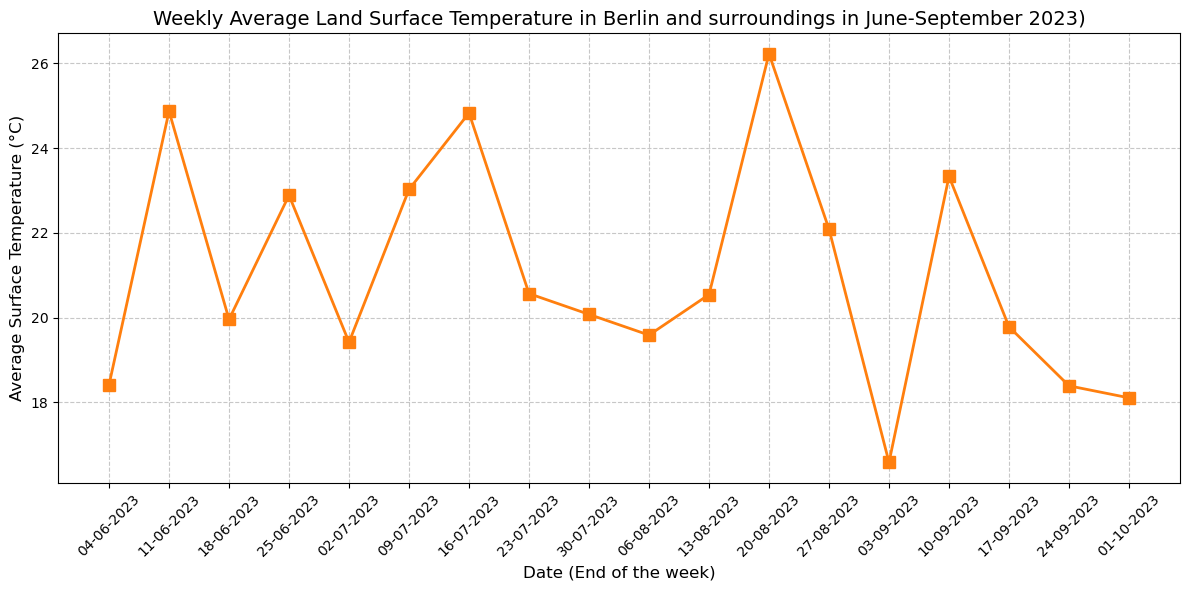

Top 3 hottest weeks (based on Average Surface Temperature):
Week ending on 2023-08-20: 26.22 °C
Week ending on 2023-06-11: 24.87 °C
Week ending on 2023-07-16: 24.83 °C


In [13]:
# 1. Spatial averaging and Time sorting
# We calculate the mean over latitude and longitude to get a single value per time step.
ds_timeseries = ds_clean["lst"].mean(dim=["lat", "lon"], skipna=True).sortby("time")

# 2. Resample data by week ('1W')
# CHANGE: We use .mean() to calculate the average temperature for the week
weekly_mean = ds_timeseries.resample(time="1W").mean()

# 3. Convert Kelvin to Celsius
weekly_mean_c = weekly_mean - 273.15

# visualizing
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the line chart
# Using color='#ff7f0e' (orange) to distinguish from the max plot
weekly_mean_c.plot.line(ax=ax, marker="s", color="#ff7f0e", linewidth=2, markersize=8)

# X-Axis Configuration (Dates)

# Set date format: Day-Month-Year (e.g., 15-07-2023)
date_form = mdates.DateFormatter("%d-%m-%Y")
ax.xaxis.set_major_formatter(date_form)

# Set tick frequency: Every week, on Sundays (byweekday=0)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=6, interval=1))

# Labels and Title in English (Updated for Mean Temp)
plt.title(f"Weekly Average Land Surface Temperature in {city_name} and surroundings in June-September 2023)", fontsize=14)
plt.ylabel("Average Surface Temperature (°C)", fontsize=12)
plt.xlabel("Date (End of the week)", fontsize=12)

# Enable grid for better readability
plt.grid(True, linestyle="--", alpha=0.7)

# Rotate date labels
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Print Statistics 
print("Top 3 hottest weeks (based on Average Surface Temperature):")

# Sort by temperature descending
top_weeks = weekly_mean_c.sortby(weekly_mean_c, ascending=False).head(3)

for t, temp in zip(top_weeks.time.values, top_weeks.values):
    date_str = str(t)[:10]
    print(f"Week ending on {date_str}: {temp:.2f} °C")

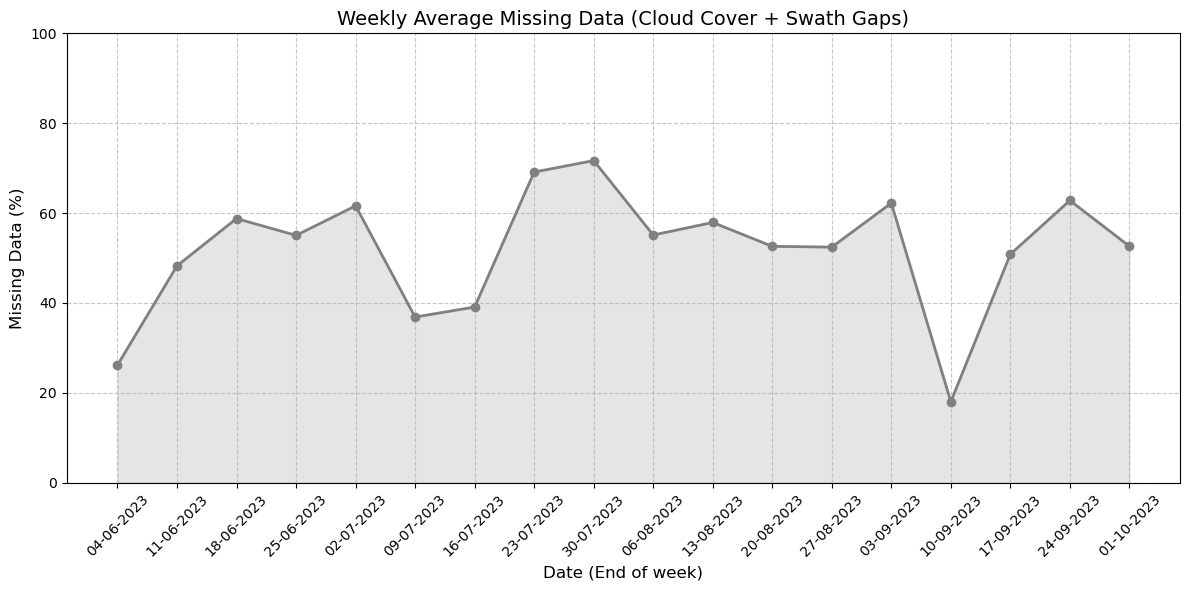

Best weeks with minimal missing data (Clear sky):
Week ending on 2023-09-10: 18.0% missing data
Week ending on 2023-06-04: 26.2% missing data
Week ending on 2023-07-09: 36.9% missing data
Week ending on 2023-07-16: 39.1% missing data
Week ending on 2023-06-11: 48.3% missing data


In [14]:
# 1. Calculate "Missing Data Fraction" for each snapshot
# .isnull() returns True (1) if data is NaN (cloud/no swath), and False (0) otherwise.
# .mean(dim=["lat", "lon"]) gives us the % of missing pixels for that specific time.
cloud_fraction = ds_clean["lst"].isnull().mean(dim=["lat", "lon"]).sortby("time")

# 2. Resample by week
# We calculate the average cloudiness for the week
weekly_cloud_pct = cloud_fraction.resample(time="1W").mean() * 100

# VISUALIZATION
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the data
# Using a bar chart (kind='bar' logic via plot) or line. 
# A line chart with filled area is often nice for "coverage".
weekly_cloud_pct.plot.line(ax=ax, marker="o", color="gray", linestyle="-", linewidth=2)

# Fill the area under the curve to emphasize "emptiness"
ax.fill_between(weekly_cloud_pct.time, weekly_cloud_pct, color="gray", alpha=0.2)

# --- X-Axis Configuration ---
date_form = mdates.DateFormatter("%d-%m-%Y")
ax.xaxis.set_major_formatter(date_form)
# Mark Sundays (end of week)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=6, interval=1))

# --- Formatting ---
plt.title("Weekly Average Missing Data (Cloud Cover + Swath Gaps)", fontsize=14)
plt.ylabel("Missing Data (%)", fontsize=12)
plt.xlabel("Date (End of week)", fontsize=12)

plt.ylim(0, 100) # Percentage is always 0-100
plt.grid(True, linestyle="--", alpha=0.7)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# --- Print Best Weeks (Least Clouds) ---
print("Best weeks with minimal missing data (Clear sky):")

# Sort by percentage ascending (lowest NaN first)
best_weeks = weekly_cloud_pct.sortby(weekly_cloud_pct, ascending=True).head(5)

for t, pct in zip(best_weeks.time.values, best_weeks.values):
    date_str = str(t)[:10]
    print(f"Week ending on {date_str}: {pct:.1f}% missing data")

Let's create illustrations to see LST distribution for the chosen dates:

Found 15 snapshots for this week.


/tmp/ipykernel_188/648341102.py:35: DeprecationWarning: self.axes is deprecated since 2022.11 in order to align with matplotlibs plt.subplots, use self.axs instead.
  for ax, t in zip(g.axes.flat, ds_week.time.values):


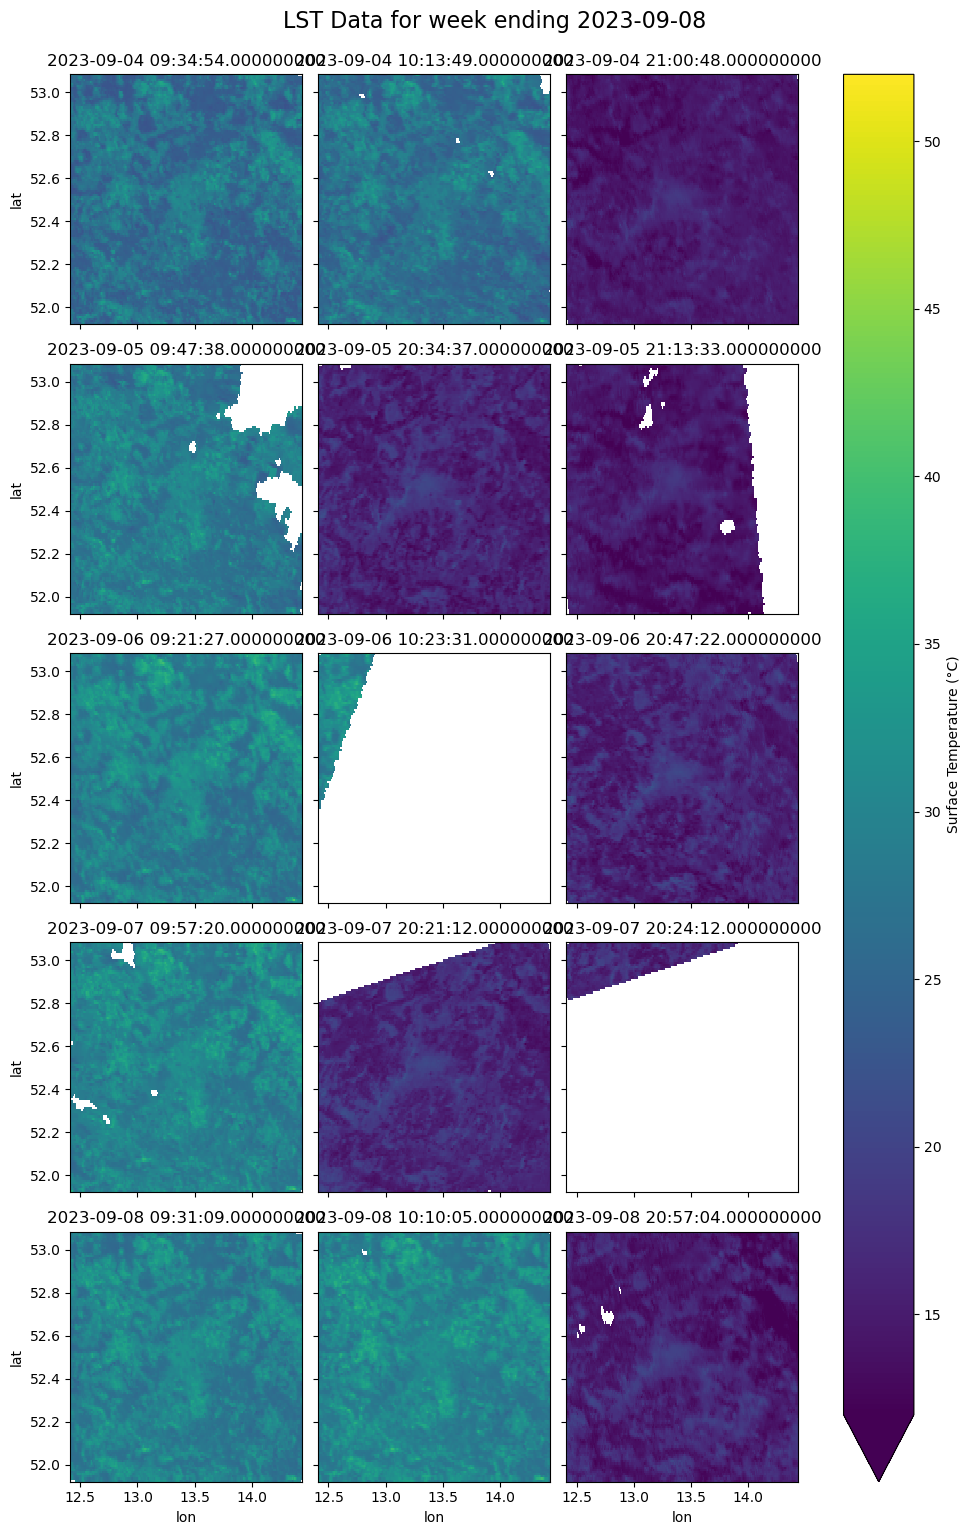

In [15]:
ds_clean = ds_clean.sortby("time") 

# 1. Select the specific week
week_start = "2023-09-04"
week_end = "2023-09-08"

# Now .sel() will work because the index is sorted
ds_week = ds_clean.sel(time=slice(week_start, week_end))

# Check if we have data
if ds_week.time.size == 0:
    print(f"No data found between {week_start} and {week_end}!")
else:
    print(f"Found {ds_week.time.size} snapshots for this week.")

    # 2. Convert Kelvin to Celsius
    ds_week_c = ds_week["lst"] - 273.15

    # 3. Plotting
    g = ds_week_c.plot(
        x="lon", 
        y="lat", 
        col="time",        # Split by time (one plot per snapshot)
        col_wrap=3,        # Number of columns in the grid (e.g. 3 images per row)
        cmap="viridis", 
        vmin=12,           # Minimum value in Celsius (~285K)
        vmax=52,           # Maximum value in Celsius (~325K)
        cbar_kwargs={"label": "Surface Temperature (°C)"} # English label
    )

    # Add a main title to the entire figure
    plt.suptitle(f"LST Data for week ending {week_end}", fontsize=16, y=1.02)

    # Format the individual subplot titles (YYYY-MM-DD HH:MM)
    for ax, t in zip(g.axes.flat, ds_week.time.values):
        # Convert numpy datetime to string and keep only up to minutes
        date_str = str(t).replace("T", " ") 
        ax.set_title(date_str)

    plt.savefig(f'illustrations/illustr_{city_name}_{week_start}_{week_end}.jpg')

Removing the dates where data is not enough:

In [16]:
timestamps_to_remove = [
    "2023-09-04T10:13:49",
    "2023-09-05T21:13:33",
    "2023-09-06T10:23:31",
    "2023-09-07T20:24:12",
    "2023-09-08T10:10:05"  
]

ds_filtered = ds_clean.drop_sel(time=timestamps_to_remove, errors="ignore")
ds_clean = ds_filtered

Exporting:

In [17]:
ds_export = ds_clean.sel(time=slice(week_start, week_end))
ds_export.to_netcdf(f"results/{city_name}_lst_{week_start}_{week_end}.nc")

In [18]:
ds_clean = ds_clean.sel(time=slice(week_start, week_end))

### Calculating the average difference between daily amplitudes in and out of the city

Reading boundary to define wht's within the city:

In [19]:
boundary = gpd.read_file(f"data/{city_name}.geojson")

In [20]:
boundary

,geometry
0,"MULTIPOLYGON (((13.39292 52.64567, 13.39285 52..."


In [21]:
boundary.explore()

In [22]:
# Making sure that ds_clean has a CRS EPSG:4326
if ds_clean.rio.crs is None:
    ds_clean.rio.write_crs("EPSG:4326", inplace=True)

In [23]:
# Making sure that boundary GeoDataFrame is in the same CRS
if boundary.crs.to_string() != "EPSG:4326":
    boundary = boundary.to_crs("EPSG:4326")

In [24]:
# Creating 'in-city' mask
# clip returns data inside of a geometry
ds_clean.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
ds_inside = ds_clean.rio.clip(boundary.geometry, drop=False, invert=False)

In [25]:
# Creating 'out-of-city' mask
ds_outside = ds_clean.rio.clip(boundary.geometry, drop=False, invert=True)

# Calculating average LST
mean_inside = ds_inside["lst"].mean(dim=["lat", "lon"]) - 273.15
mean_outside = ds_outside["lst"].mean(dim=["lat", "lon"]) - 273.15

In [26]:
# Gathering data into one DataFrame
df_res = pd.DataFrame({
    "time": ds_clean.time.values,
    "lst_city": mean_inside.values,
    "lst_suburb": mean_outside.values
}).dropna() # deleting empty rows in case if masks didn't work correctly

# adding time columns for grouping
df_res["date"] = df_res["time"].dt.date
df_res["hour"] = df_res["time"].dt.hour

print("Number of processed images:", len(df_res))

Number of processed images: 10


In [27]:
# 4. counting amplitude (morning vs evening) for each day
results = []

for date, group in df_res.groupby("date"):
    # Sentinel-3 usually flies over at around 10:00 (morning) and 21:00 (evening) local time.
    # Let's find the morning and evening measurements.
    # We can simply take min(hour) and max(hour) if there are exactly two images per day.
    
    # If there are more than 2 images, we can set strict limits, for example:
    morning_pass = group[group["hour"] < 14]
    evening_pass = group[group["hour"] >= 18]
    
    if not morning_pass.empty and not evening_pass.empty:
        # We take the average, in case there were two morning flights.
        t_morn_city = morning_pass["lst_city"].mean()
        t_even_city = evening_pass["lst_city"].mean()
        
        t_morn_suburb = morning_pass["lst_suburb"].mean()
        t_even_suburb = evening_pass["lst_suburb"].mean()
        
        # Amplitude = Maximum - Minimum (or simply abs difference)
        # It is usually hotter during the day, but in the evening there may be an “urban heat island.”
        # Let's just calculate the modulus of the temperature difference.
        amp_city = abs(t_morn_city - t_even_city)
        amp_suburb = abs(t_morn_suburb - t_even_suburb)
        
        # Difference in amplitudes (how much more “stable” or vice versa the city is)
        # If > 0, then the temperature difference in the city is greater
        delta_amp = amp_city - amp_suburb 
        
        results.append({
            "date": date,
            "amp_city": amp_city,
            "amp_suburb": amp_suburb,
            "delta_amp": delta_amp,
            "t_morn_city": t_morn_city,
            "t_even_city": t_even_city,
            "t_morn_suburb": t_morn_suburb,
            "t_even_suburb": t_even_suburb
        })

df_amplitude = pd.DataFrame(results)

# 5. Showing results
print(df_amplitude)

         date   amp_city  amp_suburb  delta_amp  t_morn_city  t_even_city  \
0  2023-09-04  11.114304   11.979014  -0.864710    27.636696    16.522392   
1  2023-09-05  11.159491   12.836613  -1.677122    29.298576    18.139085   
2  2023-09-06  11.963662   13.423618  -1.459956    30.071228    18.107566   
3  2023-09-07  11.717741   13.505483  -1.787742    30.112911    18.395170   
4  2023-09-08  12.413207   14.129691  -1.716483    29.932422    17.519214   

   t_morn_suburb  t_even_suburb  
0      26.656694      14.677679  
1      28.689202      15.852590  
2      29.433157      16.009539  
3      29.988857      16.483375  
4      29.424038      15.294348  


In [28]:
df_amplitude.to_csv(f"results/amplitudes_{city_name}.csv")

### Now let's create a vector layer of pixels containing the data on average daily temperature apmlitude (for each pixel)

In [29]:
def calculate_pixel_amplitude(ds):
    """
    Calculates the mean temperature amplitude (Morning - Evening) for each pixel
    over the entire period available in the dataset.
    """
    # Isolate hours to separate morning and evening
    # Sentinel-3 typically flies around 10-11 AM and 9-10 PM.
    # Morning: < 14 hours, Evening: >= 18 hours
    am_mask = ds['time'].dt.hour < 14
    pm_mask = ds['time'].dt.hour >= 18

    ds_am = ds.sel(time=am_mask)
    ds_pm = ds.sel(time=pm_mask)

    # Group by date to match morning and evening of the same day
    # We take the mean per pass (in case there are 2 consecutive images)
    ds_am_daily = ds_am.groupby(ds_am.time.dt.date).mean()
    ds_pm_daily = ds_pm.groupby(ds_pm.time.dt.date).mean()

    # Keep only those days where both morning AND evening data exist (date intersection)
    common_dates = np.intersect1d(ds_am_daily.date, ds_pm_daily.date)
    
    if len(common_dates) == 0:
        raise ValueError("No days with full data (morning + evening) found to calculate amplitude!")

    ds_am_common = ds_am_daily.sel(date=common_dates)
    ds_pm_common = ds_pm_daily.sel(date=common_dates)

    # Calculate the difference (Amplitude) for each day
    # abs() is used because sometimes the evening might be warmer (rare, but it happens)
    daily_amplitude = np.abs(ds_am_common["lst"] - ds_pm_common["lst"])
    
    # Average the amplitude over the entire period (creates a "mean amplitude map")
    # We also save the mean morning and evening temperatures for context
    mean_amp = daily_amplitude.mean(dim="date")
    mean_lst_am = ds_am_common["lst"].mean(dim="date")
    mean_lst_pm = ds_pm_common["lst"].mean(dim="date")

    # Assemble everything into a single Dataset
    ds_result = xr.Dataset({
        "amplitude": mean_amp,
        "lst_morning": mean_lst_am,
        "lst_evening": mean_lst_pm
    })
    
    return ds_result

def vectorise_with_data(ds_stats):
    """
    Converts an xarray with statistics into a GeoDataFrame with square polygons.
    """
    # Convert xarray to pandas DataFrame (flat table)
    # reset_index converts lat/lon coordinates into columns
    df = ds_stats.to_dataframe().reset_index().dropna()

    # Calculate square geometries
    # Define the grid step
    lat_unique = np.sort(ds_stats.lat.values)
    lon_unique = np.sort(ds_stats.lon.values)
    
    # Safety check against division by zero if the grid is only 1 pixel
    if len(lat_unique) > 1:
        dy = abs(lat_unique[1] - lat_unique[0]) / 2
    else:
        dy = 0.005 # Default value (half of 0.01)

    if len(lon_unique) > 1:
        dx = abs(lon_unique[1] - lon_unique[0]) / 2
    else:
        dx = 0.005

    # Generate polygons for each DataFrame row
    # Use list comprehension for processing speed
    geometries = [
        box(row.lon - dx, row.lat - dy, row.lon + dx, row.lat + dy)
        for row in df.itertuples()
    ]

    # Create the GeoDataFrame
    gdf = gpd.GeoDataFrame(df, geometry=geometries, crs="EPSG:4326")
    
    return gdf

# Calculate statistics (amplitude and mean LST) within xarray
try:
    ds_pixels_stats = calculate_pixel_amplitude(ds_clean)
    print("Amplitude calculation complete.")

    # Vectorize the result
    final_gdf = vectorise_with_data(ds_pixels_stats)

    # Convert Kelvin to Celsius for readability
    final_gdf["amplitude"] = final_gdf["amplitude"] # Temp difference is the same in K and C
    final_gdf["lst_morning"] = final_gdf["lst_morning"] - 273.15
    final_gdf["lst_evening"] = final_gdf["lst_evening"] - 273.15

    print(f"Done! Created a vector layer with {len(final_gdf)} cells.")
    print(final_gdf.head())

    # Save to file (for use in QGIS )
    final_gdf.to_file(f"results/{city_name}_grid_amplitude.gpkg", driver="GPKG")

except Exception as e:
    print(f"Error during calculation: {e}")

Amplitude calculation complete.
Done! Created a vector layer with 23747 cells.
         lat        lon  spatial_ref  amplitude  lst_morning  lst_evening  \
1  51.925564  12.426523            0  13.199486    30.600439    17.369215   
2  51.925564  12.436515            0  10.785883    28.884117    18.216411   
3  51.925564  12.446506            0   8.781002    27.339778    18.585986   
4  51.925564  12.456498            0   8.787579    27.588629    18.801050   
5  51.925564  12.466490            0   9.083684    27.349244    18.265560   

                                            geometry  
1  POLYGON ((12.43152 51.92059, 12.43152 51.93054...  
2  POLYGON ((12.44151 51.92059, 12.44151 51.93054...  
3  POLYGON ((12.4515 51.92059, 12.4515 51.93054, ...  
4  POLYGON ((12.46149 51.92059, 12.46149 51.93054...  
5  POLYGON ((12.47149 51.92059, 12.47149 51.93054...  
